# **KNN 3D Benchmark visual**

**Author:** Marek Šugár

Faculty of Mathematics, Physics and Informatics Comenius University in Bratislava

In [65]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Metrics to measure successfulness
from sklearn.metrics import mean_absolute_percentage_error

# ML Stuff
from sklearn.neighbors import KNeighborsRegressor

In [10]:
# General connection to the DB with data
StockDataDatabase = sqlite3.connect("StockData.db")

# Index Data (NASDAQ and S&P 500)
NASDAQ = pd.read_sql("SELECT * FROM Indexes WHERE IndexName='NASDAQ'", con=StockDataDatabase, parse_dates=["Date"])
SP500 = pd.read_sql("SELECT * FROM Indexes WHERE IndexName='S&P 500'", con=StockDataDatabase, parse_dates=["Date"])

# Stocks' Tickers
tickers = pd.read_sql("SELECT * FROM Tickers", con=StockDataDatabase)

# Market Indicators
VIX = pd.read_sql("SELECT * FROM MarketIndicators WHERE Indicator='VIX'", con=StockDataDatabase, parse_dates=["Date"])
bond_13_Week = pd.read_sql("SELECT * FROM MarketIndicators WHERE Indicator='13-Week Treasury'", con=StockDataDatabase, parse_dates=["Date"])
bond_5_Year = pd.read_sql("SELECT * FROM MarketIndicators WHERE Indicator='5-Year Treasury'", con=StockDataDatabase, parse_dates=["Date"])

# Currency exchange rates
EUR_USD = pd.read_sql("SELECT * FROM CurrencyExchange WHERE Currencies='EUR/USD'", con=StockDataDatabase, parse_dates=["Date"])
JPY_USD = pd.read_sql("SELECT * FROM CurrencyExchange WHERE Currencies='JPY/USD'", con=StockDataDatabase, parse_dates=["Date"])
GBP_USD = pd.read_sql("SELECT * FROM CurrencyExchange WHERE Currencies='GBP/USD'", con=StockDataDatabase, parse_dates=["Date"])
USD_CHF = pd.read_sql("SELECT * FROM CurrencyExchange WHERE Currencies='USD/CHF'", con=StockDataDatabase, parse_dates=["Date"])
AUD_USD = pd.read_sql("SELECT * FROM CurrencyExchange WHERE Currencies='AUD/USD'", con=StockDataDatabase, parse_dates=["Date"])
USD_CAD = pd.read_sql("SELECT * FROM CurrencyExchange WHERE Currencies='USD/CAD'", con=StockDataDatabase, parse_dates=["Date"])
NZD_USD = pd.read_sql("SELECT * FROM CurrencyExchange WHERE Currencies='NZD/USD'", con=StockDataDatabase, parse_dates=["Date"])

In [11]:
# Now we perform shifts in the data, so we obtain lagged features for the prediction
initial_columns = ["Open", "High", "Low", "Close", "Volume"]
data_types = ["VIX", "Bond13W", "Bond5Y", "NASDAQ", "SP500", "EUR/USD", "JPY/USD", "GBP/USD", "USD/CHF", "AUD/USD", "USD/CAD", "NZD/USD"]
historic_columns = []

for shift in range(1, 10):
    for column in initial_columns:
        # Market Indicators
        VIX[f"{column}_{shift}"] = VIX[f"{column}"].shift(shift)
        bond_13_Week[f"{column}_{shift}"] = bond_13_Week[f"{column}"].shift(shift)
        bond_5_Year[f"{column}_{shift}"] = bond_5_Year[f"{column}"].shift(shift)

        # Indices
        NASDAQ[f"{column}_{shift}"] = NASDAQ[f"{column}"].shift(shift)
        SP500[f"{column}_{shift}"] = SP500[f"{column}"].shift(shift)

        # Currency exchanges
        EUR_USD[f"{column}_{shift}"] = EUR_USD[f"{column}"].shift(shift)
        JPY_USD[f"{column}_{shift}"] = JPY_USD[f"{column}"].shift(shift)
        GBP_USD[f"{column}_{shift}"] = GBP_USD[f"{column}"].shift(shift)
        USD_CHF[f"{column}_{shift}"] = USD_CHF[f"{column}"].shift(shift)
        AUD_USD[f"{column}_{shift}"] = AUD_USD[f"{column}"].shift(shift)
        USD_CAD[f"{column}_{shift}"] = USD_CAD[f"{column}"].shift(shift)
        NZD_USD[f"{column}_{shift}"] = NZD_USD[f"{column}"].shift(shift)
        
        for data_type in data_types:
            historic_columns.append(f"{column}_{shift}_{data_type}")

VIX = VIX.dropna().reset_index(drop=True).add_suffix("_VIX")
bond_13_Week = bond_13_Week.dropna().reset_index(drop=True).add_suffix("_Bond13W")
bond_5_Year = bond_5_Year.dropna().reset_index(drop=True).add_suffix("_Bond5Y")

NASDAQ = NASDAQ.dropna().reset_index(drop=True).add_suffix("_NASDAQ")
SP500 = SP500.dropna().reset_index(drop=True).add_suffix("_SP500")

EUR_USD = EUR_USD.dropna().reset_index(drop=True).add_suffix("_EUR/USD")
JPY_USD = JPY_USD.dropna().reset_index(drop=True).add_suffix("_JPY/USD")
GBP_USD = GBP_USD.dropna().reset_index(drop=True).add_suffix("_GBP/USD")
USD_CHF = USD_CHF.dropna().reset_index(drop=True).add_suffix("_USD/CHF")
AUD_USD = AUD_USD.dropna().reset_index(drop=True).add_suffix("_AUD/USD")
USD_CAD = USD_CAD.dropna().reset_index(drop=True).add_suffix("_USD/CAD")
NZD_USD = NZD_USD.dropna().reset_index(drop=True).add_suffix("_NZD/USD")

In [12]:
# Data Merging for the purposes of Training
TrainingDataFrame = pd.concat([VIX, bond_13_Week, bond_5_Year, NASDAQ, SP500, EUR_USD, JPY_USD, GBP_USD, USD_CHF, AUD_USD, USD_CAD, NZD_USD], axis=1)[historic_columns].dropna()


In [68]:
performance_tracker = {}

for k in range(1, 4):
    MAPEs = []
    for training_length in range(5, 8):
        Stock_Data = pd.read_sql(f"SELECT * FROM StockData WHERE Ticker='AAPL' AND Date>='2017-09-07'", con=StockDataDatabase, parse_dates=["Date"])
        Stock_Data["Target"] = Stock_Data["Close"].shift(-1)
        Stock_Data = Stock_Data.dropna().reset_index(drop=True)

        prediction_length = 1 # Days

        for window_start in range(len(Stock_Data) - (training_length + prediction_length)):
            Training_Features = TrainingDataFrame.iloc[window_start:window_start+training_length]
            Training_Target = Stock_Data["Target"].iloc[window_start:window_start+training_length]
    
            Test_Features = TrainingDataFrame.iloc[window_start+training_length:window_start+training_length+prediction_length]
            Test_Target = Stock_Data["Target"].iloc[window_start+training_length:window_start+training_length+prediction_length]

            if Test_Features.empty or len(Training_Features) == 0:
                continue

            MODEL = KNeighborsRegressor(n_neighbors=3)

            MODEL.fit(Training_Features, Training_Target)
    
            prediction = MODEL.predict(Test_Features)

            MAPEs.append(100*mean_absolute_percentage_error(Test_Target, prediction))
        print(k, training_length, np.mean(MAPEs))

        performance_tracker[(k, training_length)] = np.mean(MAPEs)

1 5 1.8866448729258765
1 6 1.9210820305180363
1 7 1.9591550533555964
2 5 1.8866448729258765
2 6 1.9210820305180363
2 7 1.9591550533555964
3 5 1.8866448729258765
3 6 1.9210820305180363
3 7 1.9591550533555964


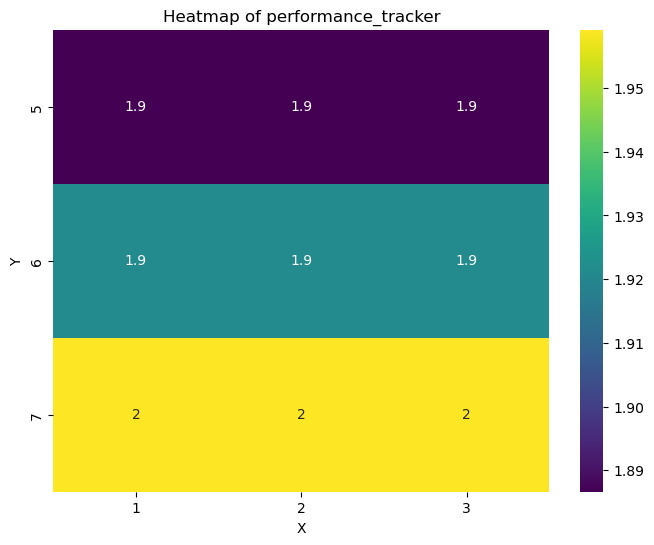

In [69]:
# Suppose performance_tracker = {(x, y): value, ...}

# Extract unique X and Y values
x_unique = np.unique([k[0] for k in performance_tracker.keys()])
y_unique = np.unique([k[1] for k in performance_tracker.keys()])

# Build 2D Z matrix
Z = np.zeros((len(y_unique), len(x_unique)))

for (x_val, y_val), val in performance_tracker.items():
    i = np.where(y_unique == y_val)[0][0]  # row index
    j = np.where(x_unique == x_val)[0][0]  # column index
    Z[i, j] = val

# Convert to DataFrame for seaborn
df = pd.DataFrame(Z, index=y_unique, columns=x_unique)

# Plot heatmap
plt.figure(figsize=(8,6))
sns.heatmap(df, cmap='viridis', annot=True)
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Heatmap of performance_tracker')
plt.show()
